# Dataset

- Coder: Lenin G. Falconi

## Goal:

- To format dataset in question, answer and context
- To use some LLM in order to retrieve or build questions from the data



In [4]:
import os
from huggingface_hub import login
token = os.getenv('HUGGINGFACE_TOKEN')
login(token)

In [16]:
from datasets import load_dataset
dataset_path = 'LeninGF/autotrain-data-robberyclassification'
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset(dataset_path)

In [17]:
from pprint import pprint
pprint(ds['train'][100])

{'labels': 'ROBO A DOMICILIO',
 'relato': 'es el caso señor fiscal que el día 17 de agosto del 2018 '
           'aproximadamente a las 11h00 salí de mi domicilio ubicado en la '
           'cooperativa 8 de marzo calle n pasaje e20j lote 3 número s8 45 '
           'sector puente dos autopista general rumiñahui a realizar una '
           'gestión de pagos al retornar a las 13h20 pude observar que tres '
           'sujetos salían de mi domicilio y afuera ase encontraba estacionado '
           'un automóvil al ingresar me percate que me habías sustraído dos '
           'televisores marca lg 4k de 65 pulgadas un televisor marca samsung '
           'hd de 32 pulgadas un play station pro 1tb un nintendo switch '
           'cuatro whisky un lote de joyas de plata y oro valorado en 3 450 '
           'dolares y 40 dólares en efectivo motivo por la cual pongo la '
           'respectiva denuncia con la finalidad de que se realicen las '
           'investigaciones del caso más informaci

## Histograma cantidad de palabras por relato

In [26]:
def count_words(sample):
    sample['word_count'] = len(sample['relato'].split())
    return sample

ds = ds.map(count_words, batched=False)

Map:   0%|          | 0/341669 [00:00<?, ? examples/s]

In [27]:
pprint(ds['train'][100])

{'labels': 'ROBO A DOMICILIO',
 'relato': 'es el caso señor fiscal que el día 17 de agosto del 2018 '
           'aproximadamente a las 11h00 salí de mi domicilio ubicado en la '
           'cooperativa 8 de marzo calle n pasaje e20j lote 3 número s8 45 '
           'sector puente dos autopista general rumiñahui a realizar una '
           'gestión de pagos al retornar a las 13h20 pude observar que tres '
           'sujetos salían de mi domicilio y afuera ase encontraba estacionado '
           'un automóvil al ingresar me percate que me habías sustraído dos '
           'televisores marca lg 4k de 65 pulgadas un televisor marca samsung '
           'hd de 32 pulgadas un play station pro 1tb un nintendo switch '
           'cuatro whisky un lote de joyas de plata y oro valorado en 3 450 '
           'dolares y 40 dólares en efectivo motivo por la cual pongo la '
           'respectiva denuncia con la finalidad de que se realicen las '
           'investigaciones del caso más informaci

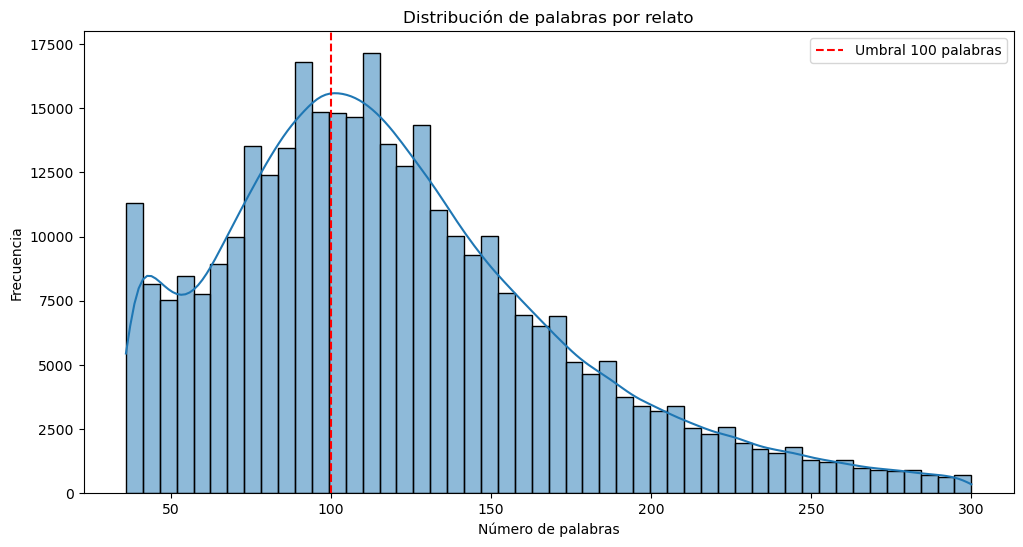

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear histograma
plt.figure(figsize=(12, 6))
sns.histplot(ds["train"]["word_count"], bins=50, kde=True)
plt.title("Distribución de palabras por relato")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.axvline(x=100, color="r", linestyle="--", label="Umbral 100 palabras")
plt.legend()
plt.show()